# Aupa — Análisis Completo del Proyecto Data
### Reto Inetum · Bootcamp BBK The Bridge · Equipo 4 Data
**Lead:** Naia | **Equipo:** Andoni, Unai, Fátima | **Fecha:** Junio 2026

---

Este notebook es el resumen ejecutivo del trabajo completo del equipo de datos. Recorre todos los hallazgos importantes: el estado del dataset maestro, la distribución del Local Score, los resultados de ambos modelos y las decisiones clave que hemos tomado con su justificación. No es un notebook operacional sino de comunicación: está pensado para el jurado, para los profesores y para que cualquier miembro del equipo pueda ponerse al día rápidamente.

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import json
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.25,
    'grid.linestyle': '--',
    'font.family': 'sans-serif',
})

PALETTE  = ['#1D9E75', '#378ADD', '#EF9F27', '#D85A30', '#7F77DD', '#888780']
P_TEAL   = '#1D9E75'
P_BLUE   = '#378ADD'
P_AMBER  = '#EF9F27'
P_CORAL  = '#D85A30'
P_PURPLE = '#7F77DD'
P_GRAY   = '#888780'

df = pd.read_csv('aupa_master_v5.csv', encoding='utf-8-sig')
print(f"Dataset cargado: {len(df):,} filas x {len(df.columns)} columnas")

Dataset cargado: 4,655 filas x 27 columnas


## 1. El dataset maestro en números

Partimos de 39 datasets de Open Data Euskadi. Después de la integración con Google Maps Places API, el pipeline de limpieza y la incorporación de tiendas gourmet del iceberg de Fátima, llegamos a 4.655 lugares.

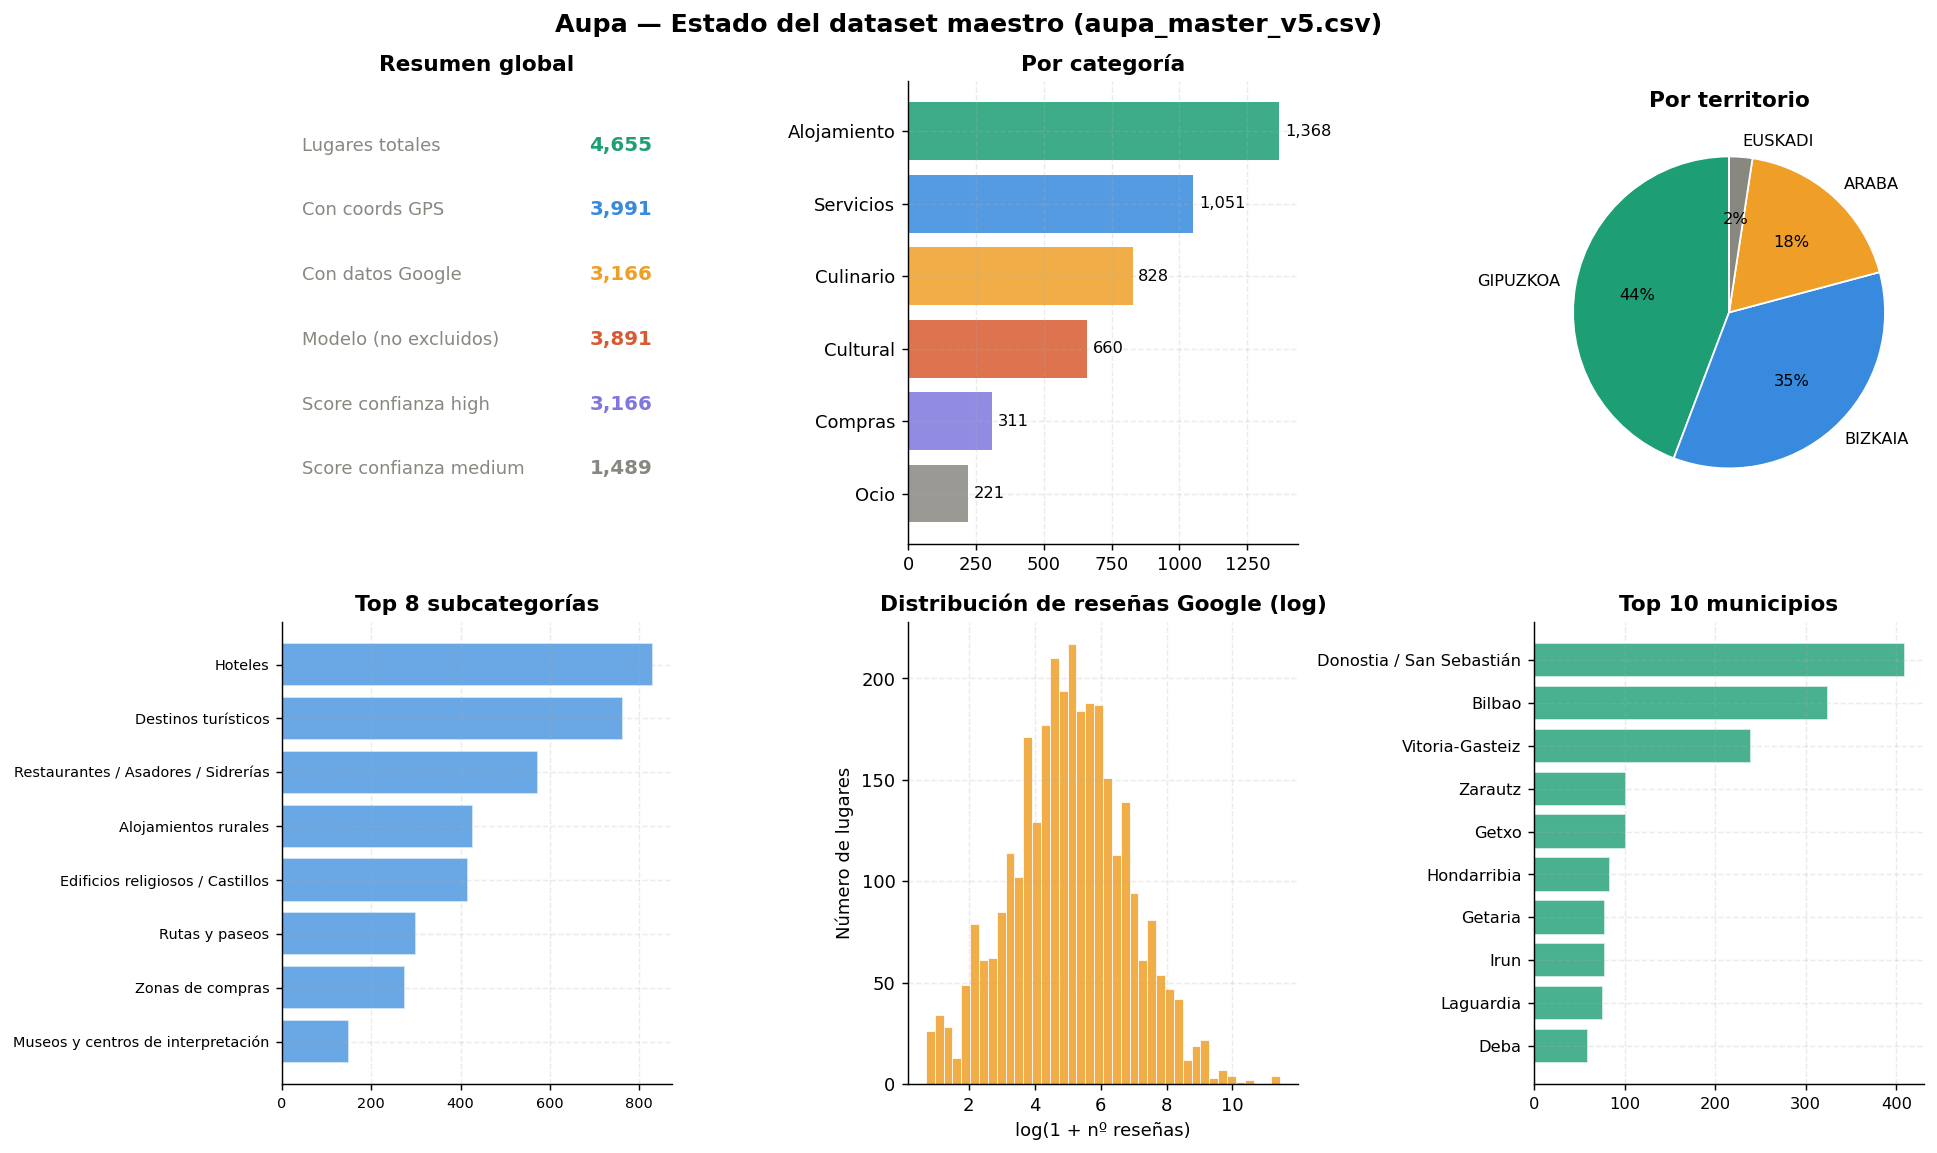

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle('Aupa — Estado del dataset maestro (aupa_master_v5.csv)', fontsize=14, fontweight='bold')

stats_globales = {
    'Lugares totales': len(df),
    'Con coords GPS': df['mappable'].sum(),
    'Con datos Google': df['has_google_data'].sum(),
    'Modelo (no excluidos)': (~df['excluir_modelo']).sum(),
    'Score confianza high': (df['local_ratio_confidence'] == 'high').sum(),
    'Score confianza medium': (df['local_ratio_confidence'] == 'medium').sum(),
}
ax = axes[0][0]
ax.axis('off')
for idx, (k, v) in enumerate(stats_globales.items()):
    color = PALETTE[idx % len(PALETTE)]
    ax.text(0.05, 0.85 - idx * 0.14, k, fontsize=10, color=P_GRAY, transform=ax.transAxes)
    ax.text(0.95, 0.85 - idx * 0.14, f'{v:,}', fontsize=11, fontweight='bold',
            color=color, transform=ax.transAxes, ha='right')
ax.set_title('Resumen global', fontweight='bold')

cat_counts = df['categoria'].value_counts().head(6)
axes[0][1].barh(cat_counts.index, cat_counts.values, color=PALETTE[:len(cat_counts)], alpha=0.85)
for i, (v, n) in enumerate(zip(cat_counts.values, cat_counts.index)):
    axes[0][1].text(v + 20, i, f'{v:,}', va='center', fontsize=9)
axes[0][1].set_title('Por categoría', fontweight='bold')
axes[0][1].invert_yaxis()

terr = df['territorio'].value_counts()
colors_t = [P_TEAL, P_BLUE, P_AMBER, P_GRAY, P_CORAL]
wedges, texts, autotexts = axes[0][2].pie(
    terr.values, labels=terr.index, colors=colors_t,
    autopct='%1.0f%%', startangle=90,
    textprops={'fontsize': 9},
    wedgeprops={'edgecolor': 'white', 'linewidth': 1}
)
axes[0][2].set_title('Por territorio', fontweight='bold')

top_subcat = df['subcategoria'].value_counts().head(8)
axes[1][0].barh(top_subcat.index, top_subcat.values,
                color=P_BLUE, alpha=0.75, edgecolor='white')
axes[1][0].set_title('Top 8 subcategorías', fontweight='bold')
axes[1][0].invert_yaxis()
axes[1][0].tick_params(labelsize=8)

df['google_num_reviews_log'] = np.log1p(df['google_num_reviews'])
axes[1][1].hist(df[df['google_num_reviews'] > 0]['google_num_reviews_log'],
                bins=40, color=P_AMBER, alpha=0.85, edgecolor='white', linewidth=0.5)
axes[1][1].set_xlabel('log(1 + nº reseñas)')
axes[1][1].set_ylabel('Número de lugares')
axes[1][1].set_title('Distribución de reseñas Google (log)', fontweight='bold')

mun_top = df['municipio'].value_counts().head(10)
axes[1][2].barh(mun_top.index, mun_top.values, color=P_TEAL, alpha=0.8, edgecolor='white')
axes[1][2].set_title('Top 10 municipios', fontweight='bold')
axes[1][2].invert_yaxis()
axes[1][2].tick_params(labelsize=9)

plt.tight_layout()
plt.savefig('fig_analisis_dataset.png', bbox_inches='tight', dpi=130)
plt.show()

## 2. El Local Score: distribución y ejemplos reales

El Local Score va de 0 (muy turístico) a 0.8 en nuestro dataset. El 0 absoluto no aparece porque incluso el hotel más turístico tiene algo de autenticidad local. El máximo teórico es 1 pero en la práctica no existe un lugar con las 5 señales perfectamente locales.

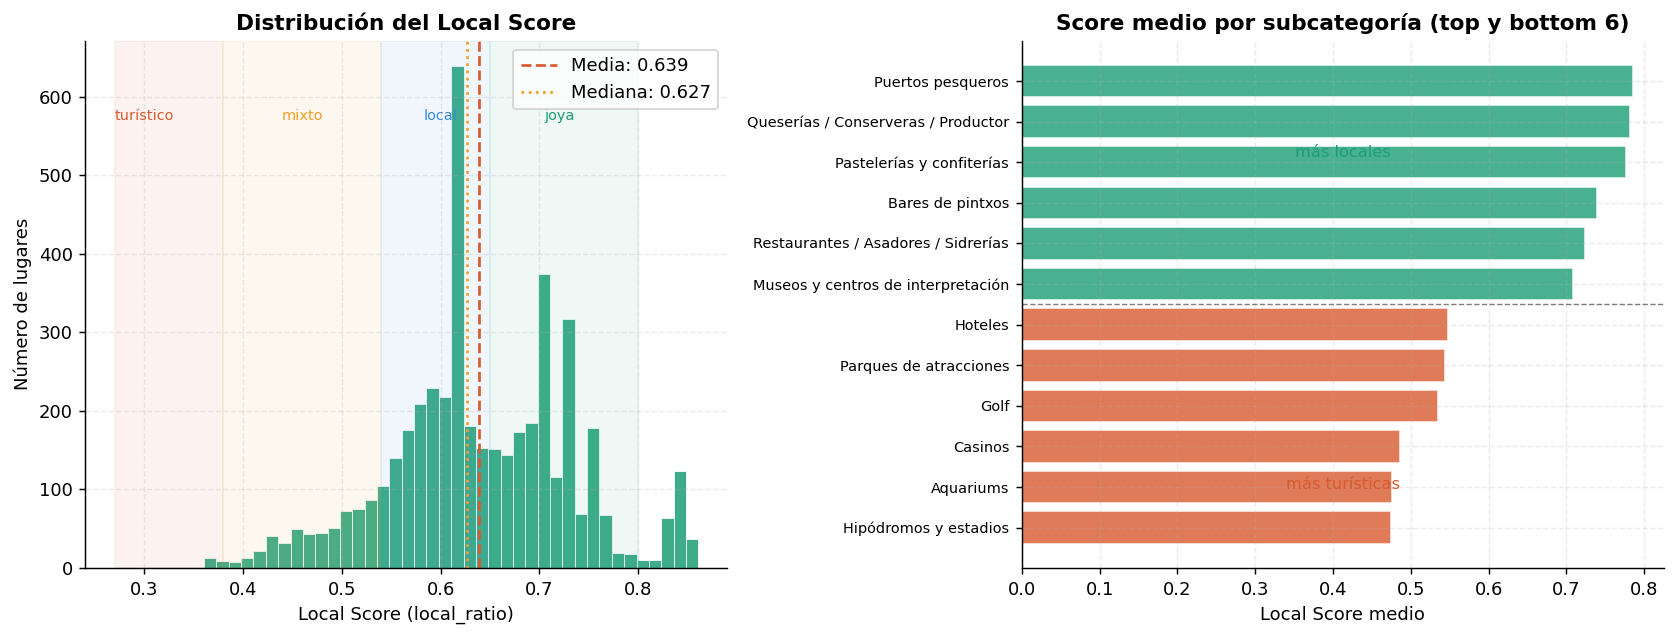

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

df_valid = df.dropna(subset=['local_ratio'])

axes[0].hist(df_valid['local_ratio'], bins=40,
             color=P_TEAL, alpha=0.85, edgecolor='white', linewidth=0.5)
axes[0].axvline(df_valid['local_ratio'].mean(), color=P_CORAL, linestyle='--',
                linewidth=1.5, label=f"Media: {df_valid['local_ratio'].mean():.3f}")
axes[0].axvline(df_valid['local_ratio'].median(), color=P_AMBER, linestyle=':',
                linewidth=1.5, label=f"Mediana: {df_valid['local_ratio'].median():.3f}")
axes[0].set_xlabel('Local Score (local_ratio)')
axes[0].set_ylabel('Número de lugares')
axes[0].set_title('Distribución del Local Score', fontweight='bold')
axes[0].legend()

bins_labels = [(0.27, 0.38, P_CORAL), (0.38, 0.54, P_AMBER),
               (0.54, 0.65, P_BLUE), (0.65, 0.80, P_TEAL)]
for lo, hi, col in bins_labels:
    mask = (df_valid['local_ratio'] >= lo) & (df_valid['local_ratio'] < hi)
    n = mask.sum()
    axes[0].axvspan(lo, hi, alpha=0.07, color=col)

for ax in [axes[0]]:
    ax.text(0.30, ax.get_ylim()[1]*0.85, 'turístico', fontsize=8, color=P_CORAL, ha='center')
    ax.text(0.46, ax.get_ylim()[1]*0.85, 'mixto', fontsize=8, color=P_AMBER, ha='center')
    ax.text(0.60, ax.get_ylim()[1]*0.85, 'local', fontsize=8, color=P_BLUE, ha='center')
    ax.text(0.72, ax.get_ylim()[1]*0.85, 'joya', fontsize=8, color=P_TEAL, ha='center')

subcat_means = df_valid.groupby('subcategoria')['local_ratio'].mean().sort_values()
top_bottom = pd.concat([subcat_means.head(6), subcat_means.tail(6)])
colors_sb = [P_CORAL]*6 + [P_TEAL]*6
axes[1].barh(range(len(top_bottom)), top_bottom.values,
             color=colors_sb, alpha=0.8, edgecolor='white')
axes[1].set_yticks(range(len(top_bottom)))
axes[1].set_yticklabels([s[:35] for s in top_bottom.index], fontsize=8)
axes[1].axhline(5.5, color='gray', linestyle='--', linewidth=0.8)
axes[1].set_xlabel('Local Score medio')
axes[1].set_title('Score medio por subcategoría (top y bottom 6)', fontweight='bold')
axes[1].text(0.5, 0.15, 'más turísticas', transform=axes[1].transAxes,
             color=P_CORAL, fontsize=9, ha='center')
axes[1].text(0.5, 0.78, 'más locales', transform=axes[1].transAxes,
             color=P_TEAL, fontsize=9, ha='center')

plt.tight_layout()
plt.savefig('fig_local_score_analisis.png', bbox_inches='tight', dpi=130)
plt.show()

### Tabla: joyas locales reales en Bilbao

Después de ver la distribución agregada, bajamos al nivel de lugar individual. Mostramos las 15 joyas locales con mayor Local Score en Bilbao entre los registros con confianza HIGH, es decir, aquellos que tienen match real en Google Maps.

**¿Por qué filtramos por confianza HIGH?** Porque los registros con confianza MEDIUM tienen el score calculado principalmente a partir de la categoría y el municipio, sin los datos reales de Google (rating y número de reseñas). Son válidos para el modelo, pero para una validación de sentido común es más ilustrativo ver los lugares que tienen todas las señales activas.

**¿Qué esperamos ver?** Los primeros puestos deberían ser bares de pintxos y restaurantes de cocina vasca con pocas reseñas en Google pero valoración alta. Si eso es lo que aparece, el modelo está funcionando correctamente.

In [12]:
print("Las 15 joyas locales con mayor score en Bilbao (confianza high):")
bilbao = df[
    (df['municipio'].str.lower() == 'bilbao') &
    (df['local_ratio_confidence'] == 'high')
].nlargest(15, 'local_ratio')[
    ['nombre', 'subcategoria', 'local_ratio', 'google_rating', 'google_num_reviews']
]
bilbao['local_score_100'] = (bilbao['local_ratio'] * 100).round().astype(int)
print(bilbao[['nombre', 'subcategoria', 'local_score_100', 'google_rating', 'google_num_reviews']].to_string())

print()
print("Los 10 más turísticos del dataset:")
turisticos = df.nsmallest(10, 'local_ratio')[
    ['nombre', 'subcategoria', 'municipio', 'local_ratio', 'google_num_reviews']
]
turisticos['local_score_100'] = (turisticos['local_ratio'] * 100).round().astype(int)
print(turisticos[['nombre', 'subcategoria', 'municipio', 'local_score_100', 'google_num_reviews']].to_string())

Las 15 joyas locales con mayor score en Bilbao (confianza high):
                        nombre                         subcategoria  local_score_100  google_rating  google_num_reviews
3841               Galtzagorri  Restaurantes / Asadores / Sidrerías               78            4.4                 7.0
593                    Sukalde                     Bares de pintxos               78            4.5                22.0
4174   La despensa de Etxanobe  Restaurantes / Asadores / Sidrerías               78            5.0                 3.0
3699                  Jauregia  Restaurantes / Asadores / Sidrerías               77            5.0                11.0
4067  Bistró Guggenheim Bilbao  Restaurantes / Asadores / Sidrerías               76            5.0                 8.0
590             Bar Guggenheim                     Bares de pintxos               76            4.7                44.0
591            El Huevo Berria                     Bares de pintxos               74           

## 3. Análisis de las 4 señales del Local Score

Vemos cómo se comporta cada señal para entender qué está aprendiendo el modelo.

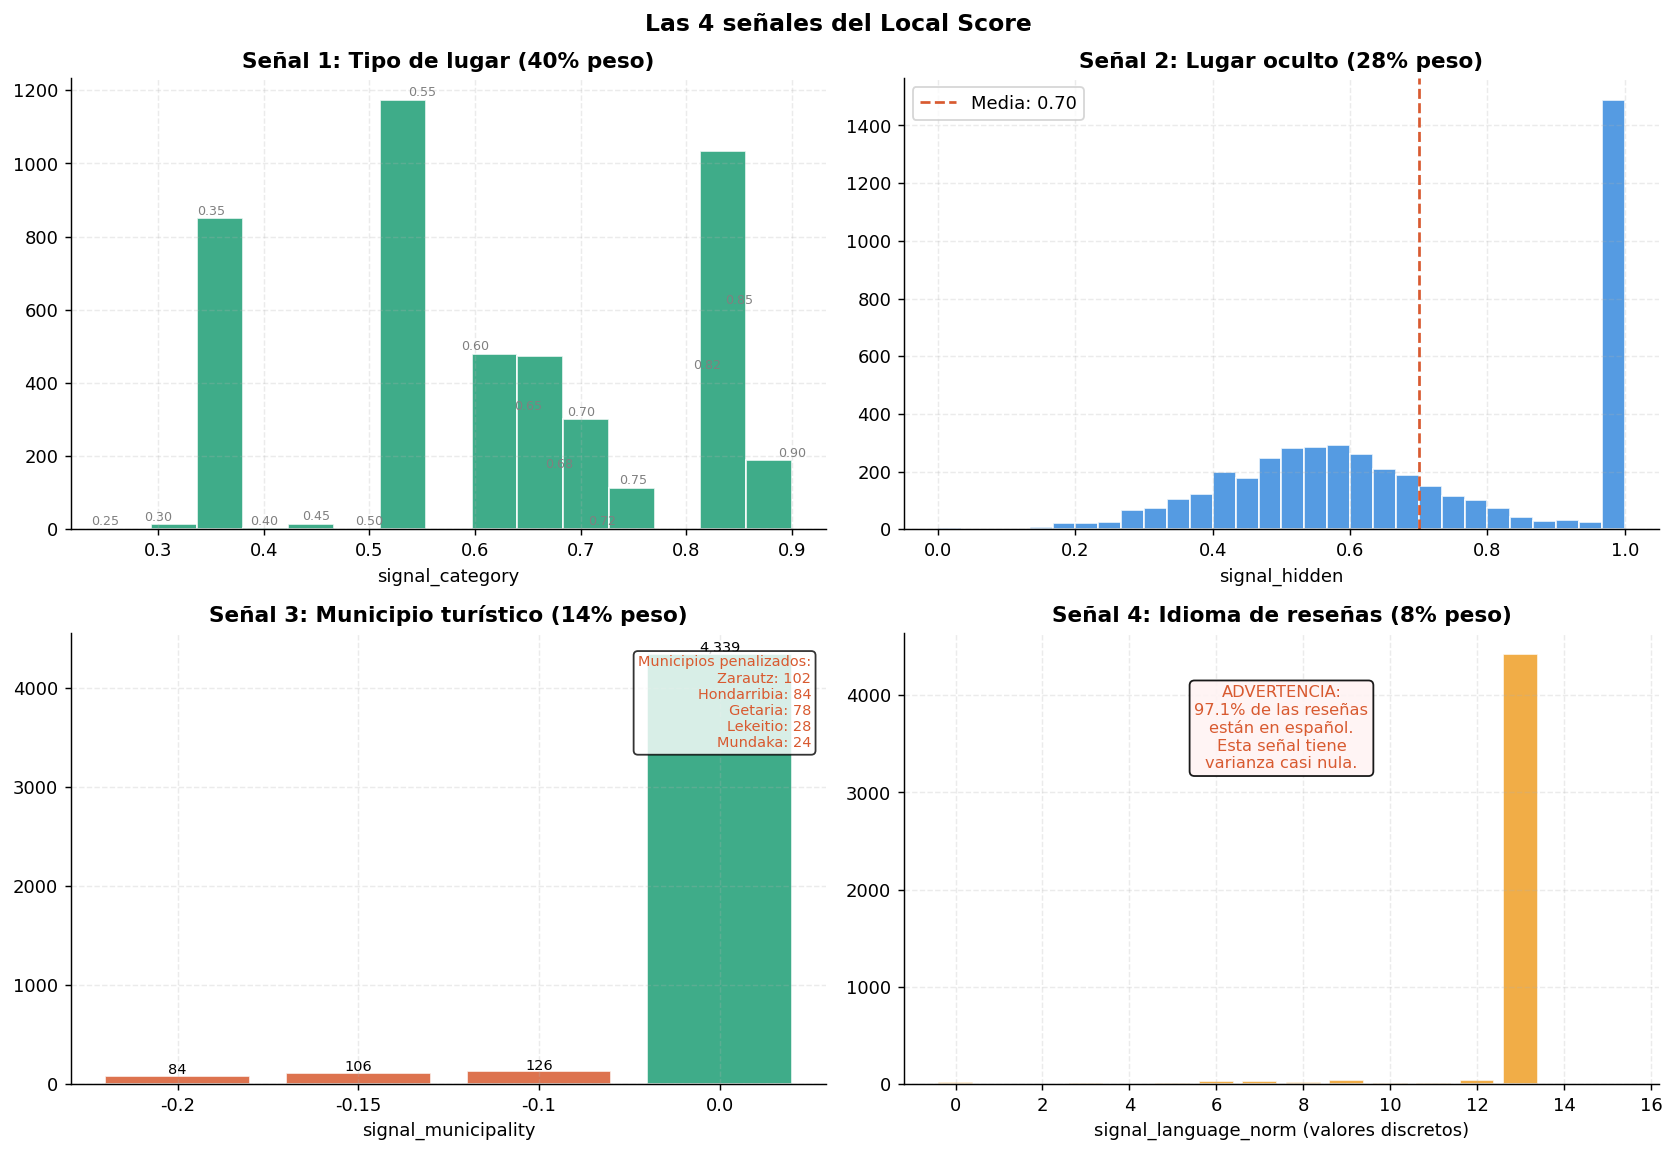

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle('Las 4 señales del Local Score', fontsize=13, fontweight='bold')


axes[0][0].hist(df['signal_category'].dropna(), bins=15,
                color=P_TEAL, alpha=0.85, edgecolor='white')
axes[0][0].set_title('Señal 1: Tipo de lugar (40% peso)', fontweight='bold')
axes[0][0].set_xlabel('signal_category')
freq = df['signal_category'].value_counts().sort_index()
for v in freq.index:
    axes[0][0].text(v, freq[v] + 10, f'{v:.2f}', ha='center', fontsize=7, color='gray')


axes[0][1].hist(df['signal_hidden'].dropna(), bins=30,
                color=P_BLUE, alpha=0.85, edgecolor='white')
axes[0][1].set_title('Señal 2: Lugar oculto (28% peso)', fontweight='bold')
axes[0][1].set_xlabel('signal_hidden')
axes[0][1].axvline(df['signal_hidden'].mean(), color=P_CORAL, linestyle='--',
                   label=f"Media: {df['signal_hidden'].mean():.2f}")
axes[0][1].legend()


munic_dist = df['signal_municipality'].value_counts().sort_index()
colors_m = [P_CORAL if v < 0 else P_TEAL for v in munic_dist.index]
bars = axes[1][0].bar(munic_dist.index.astype(str), munic_dist.values,
                      color=colors_m, alpha=0.85, edgecolor='white')
axes[1][0].set_title('Señal 3: Municipio turístico (14% peso)', fontweight='bold')
axes[1][0].set_xlabel('signal_municipality')
for bar, v in zip(bars, munic_dist.values):
    axes[1][0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                    f'{v:,}', ha='center', fontsize=8)
municipios_penalizados = df[df['signal_municipality'] < 0]['municipio'].value_counts()
txt = '\n'.join([f"{m}: {n}" for m, n in municipios_penalizados.items()])
axes[1][0].text(0.98, 0.95, f"Municipios penalizados:\n{txt}",
                transform=axes[1][0].transAxes, ha='right', va='top',
                fontsize=8, color=P_CORAL,
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))


lang_counts = df['signal_language_norm'].value_counts().sort_index()
axes[1][1].bar(range(len(lang_counts)), lang_counts.values,
               color=P_AMBER, alpha=0.85, edgecolor='white')
axes[1][1].set_title('Señal 4: Idioma de reseñas (8% peso)', fontweight='bold')
axes[1][1].set_xlabel('signal_language_norm (valores discretos)')
axes[1][1].text(0.5, 0.7,
                'ADVERTENCIA:\n97.1% de las reseñas\nestán en español.\nEsta señal tiene\nvarianza casi nula.',
                transform=axes[1][1].transAxes, ha='center', fontsize=9,
                color=P_CORAL, bbox=dict(boxstyle='round', facecolor='#fff3f3', alpha=0.9))


plt.tight_layout()
plt.savefig('fig_senales_local_score.png', bbox_inches='tight', dpi=130)
plt.show()

## 4. Resultados del Modelo 1: GradientBoosting

Resumimos los resultados clave del modelo supervisado que predice el local_ratio.

Resultados cargados desde modelos/resultados_modelo1.json


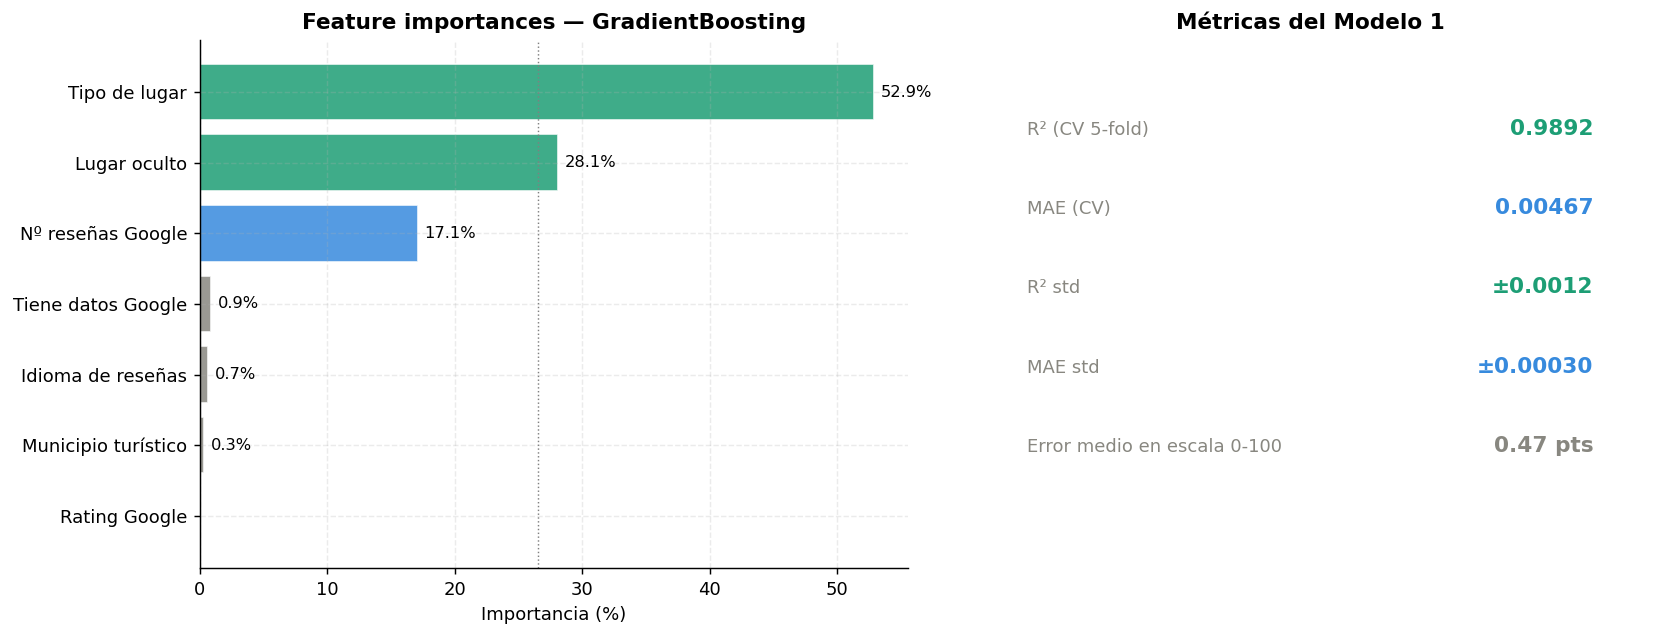


Interpretación:
  R²=0.9892 significa que el modelo explica el 98.9% de la varianza del local_ratio.
  MAE=0.00467 significa que el error medio de predicción es de 0.47 puntos sobre escala 0-100.
  La señal de idioma tiene importancia ≈0%: es semánticamente válida pero estadísticamente muerta
  en este dataset porque el 97.1% de las reseñas están en español.


In [14]:
try:
    with open('modelos/resultados_modelo1.json') as f:
        res1 = json.load(f)
    print("Resultados cargados desde modelos/resultados_modelo1.json")
except FileNotFoundError:
    res1 = {
        'cv_mae_mean': 0.00447, 'cv_mae_std': 0.00013,
        'cv_r2_mean': 0.9932, 'cv_r2_std': 0.0004,
        'feature_importances': {
            'google_num_reviews': 0.3860, 'signal_hidden': 0.3364,
            'signal_category': 0.2650, 'has_google_data': 0.0064,
            'signal_municipality': 0.0041, 'signal_language_norm': 0.0021,
            'google_rating': 0.0000
        }
    }
    print("Resultados hardcodeados (ejecuta modelo_localscore.ipynb primero)")

fi = pd.Series(res1['feature_importances']).sort_values()
labels_map = {
    'google_num_reviews': 'Nº reseñas Google',
    'signal_hidden': 'Lugar oculto',
    'signal_category': 'Tipo de lugar',
    'has_google_data': 'Tiene datos Google',
    'signal_municipality': 'Municipio turístico',
    'signal_language_norm': 'Idioma de reseñas',
    'google_rating': 'Rating Google'
}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

colors_fi = [P_TEAL if v > 0.25 else P_BLUE if v > 0.05 else P_GRAY for v in fi.values]
bars = axes[0].barh([labels_map.get(k, k) for k in fi.index], fi.values * 100,
                    color=colors_fi, alpha=0.85, edgecolor='white')
for bar, val in zip(bars, fi.values * 100):
    if val > 0.3:
        axes[0].text(val + 0.5, bar.get_y() + bar.get_height()/2,
                     f'{val:.1f}%', va='center', fontsize=9)
axes[0].set_xlabel('Importancia (%)')
axes[0].set_title('Feature importances — GradientBoosting', fontweight='bold')
axes[0].axvline(26.5, color='gray', linestyle=':', linewidth=0.8)

metricas = {
    'R² (CV 5-fold)': f"{res1['cv_r2_mean']:.4f}",
    'MAE (CV)': f"{res1['cv_mae_mean']:.5f}",
    'R² std': f"±{res1['cv_r2_std']:.4f}",
    'MAE std': f"±{res1['cv_mae_std']:.5f}",
    'Error medio en escala 0-100': f"{res1['cv_mae_mean']*100:.2f} pts",
}
axes[1].axis('off')
axes[1].set_title('Métricas del Modelo 1', fontweight='bold')
for i, (k, v) in enumerate(metricas.items()):
    color = P_TEAL if 'R²' in k and '±' not in k else P_BLUE if 'MAE' in k and '±' not in k else P_GRAY
    axes[1].text(0.1, 0.82 - i * 0.15, k, fontsize=10, color=P_GRAY, transform=axes[1].transAxes)
    axes[1].text(0.9, 0.82 - i * 0.15, v, fontsize=12, fontweight='bold',
                 color=color, transform=axes[1].transAxes, ha='right')

plt.tight_layout()
plt.savefig('fig_modelo1_resumen.png', bbox_inches='tight', dpi=130)
plt.show()

print(f"\nInterpretación:")
print(f"  R²={res1['cv_r2_mean']:.4f} significa que el modelo explica el {res1['cv_r2_mean']*100:.1f}% de la varianza del local_ratio.")
print(f"  MAE={res1['cv_mae_mean']:.5f} significa que el error medio de predicción es de {res1['cv_mae_mean']*100:.2f} puntos sobre escala 0-100.")
print(f"  La señal de idioma tiene importancia ≈0%: es semánticamente válida pero estadísticamente muerta")
print(f"  en este dataset porque el 97.1% de las reseñas están en español.")

## 5. Resultados del Modelo 2: Clustering KMeans

Resumimos los resultados clave del modelo de segmentación de usuarios.

Resultados cargados desde modelos/resultados_modelo2.json


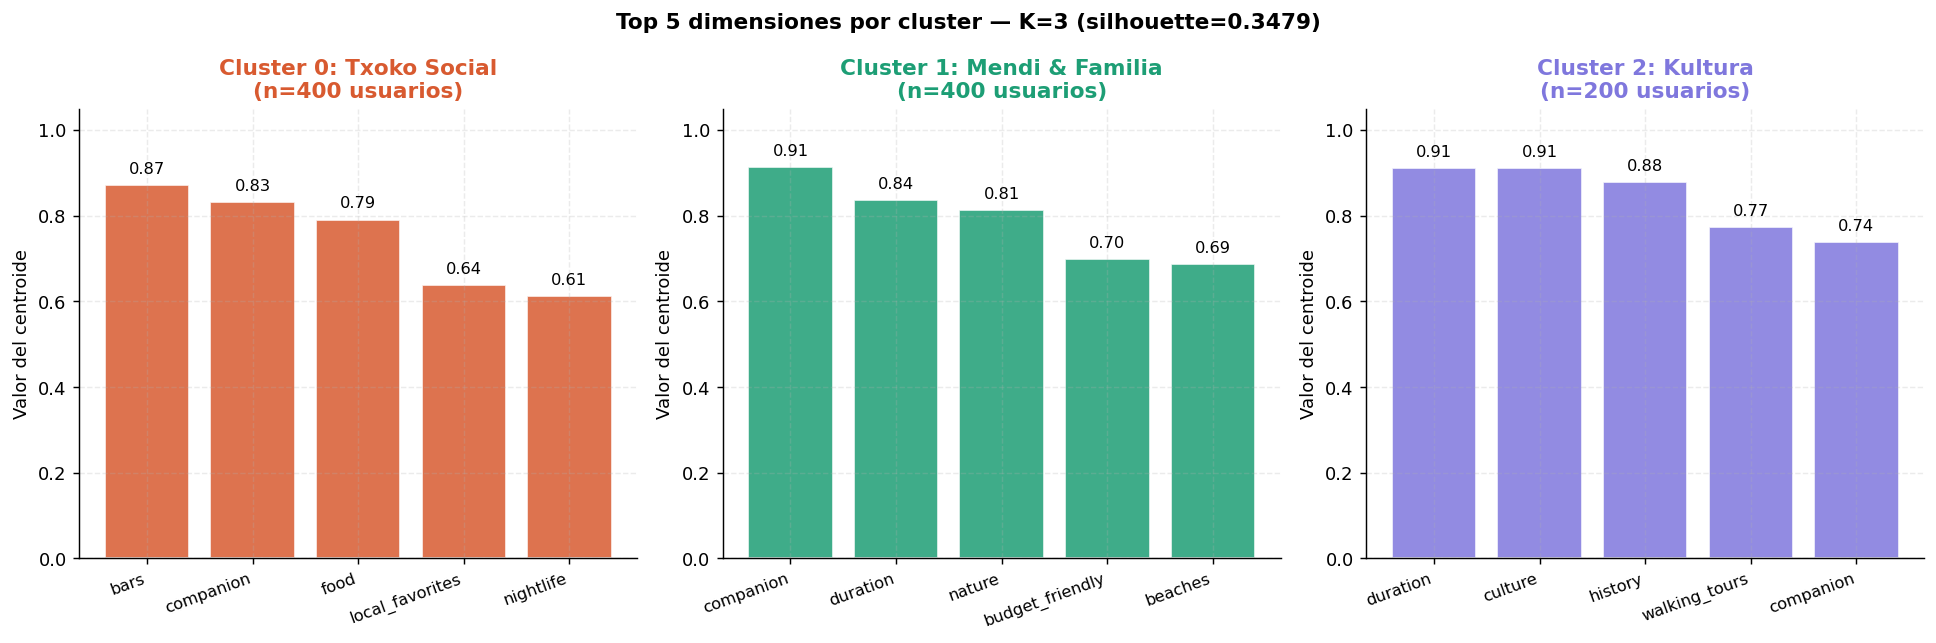

In [15]:
try:
    with open('modelos/resultados_modelo2.json') as f:
        res2 = json.load(f)
    print("Resultados cargados desde modelos/resultados_modelo2.json")
except FileNotFoundError:
    res2 = {
        'k_optimo': 3, 'silhouette': 0.3479,
        'clusters': {
            '0': {'nombre': 'Txoko Social',    'n': 400,
                  'top5_dims': {'bars': 0.87, 'companion': 0.83, 'food': 0.79, 'local_favorites': 0.64, 'nightlife': 0.61}},
            '1': {'nombre': 'Mendi & Familia', 'n': 400,
                  'top5_dims': {'companion': 0.91, 'duration': 0.84, 'nature': 0.81, 'budget_friendly': 0.70, 'beaches': 0.69}},
            '2': {'nombre': 'Kultura',         'n': 200,
                  'top5_dims': {'duration': 0.91, 'culture': 0.91, 'history': 0.88, 'walking_tours': 0.77, 'companion': 0.74}},
        }
    }
    print("Resultados hardcodeados (ejecuta modelo_clustering.ipynb primero)")

colores_clusters = [P_CORAL, P_TEAL, P_PURPLE]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for idx, (cid, c) in enumerate(res2['clusters'].items()):
    ax = axes[idx]
    dims = list(c['top5_dims'].keys())
    vals = list(c['top5_dims'].values())
    bars = ax.bar(range(len(dims)), vals,
                  color=colores_clusters[idx], alpha=0.85, edgecolor='white')
    ax.set_xticks(range(len(dims)))
    ax.set_xticklabels(dims, rotation=20, ha='right', fontsize=9)
    ax.set_ylim(0, 1.05)
    ax.set_ylabel('Valor del centroide')
    ax.set_title(f"Cluster {cid}: {c['nombre']}\n(n={c['n']} usuarios)",
                 fontweight='bold', color=colores_clusters[idx])
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'{val:.2f}', ha='center', va='bottom', fontsize=9)

plt.suptitle(f"Top 5 dimensiones por cluster — K=3 (silhouette={res2['silhouette']:.4f})",
             fontweight='bold')
plt.tight_layout()
plt.savefig('fig_modelo2_clusters.png', bbox_inches='tight', dpi=130)
plt.show()

## 6. Hallazgos clave y advertencias

Documentamos aquí los hallazgos más importantes que no están en la memoria del proyecto pero que son relevantes para el jurado y para las decisiones de producto.

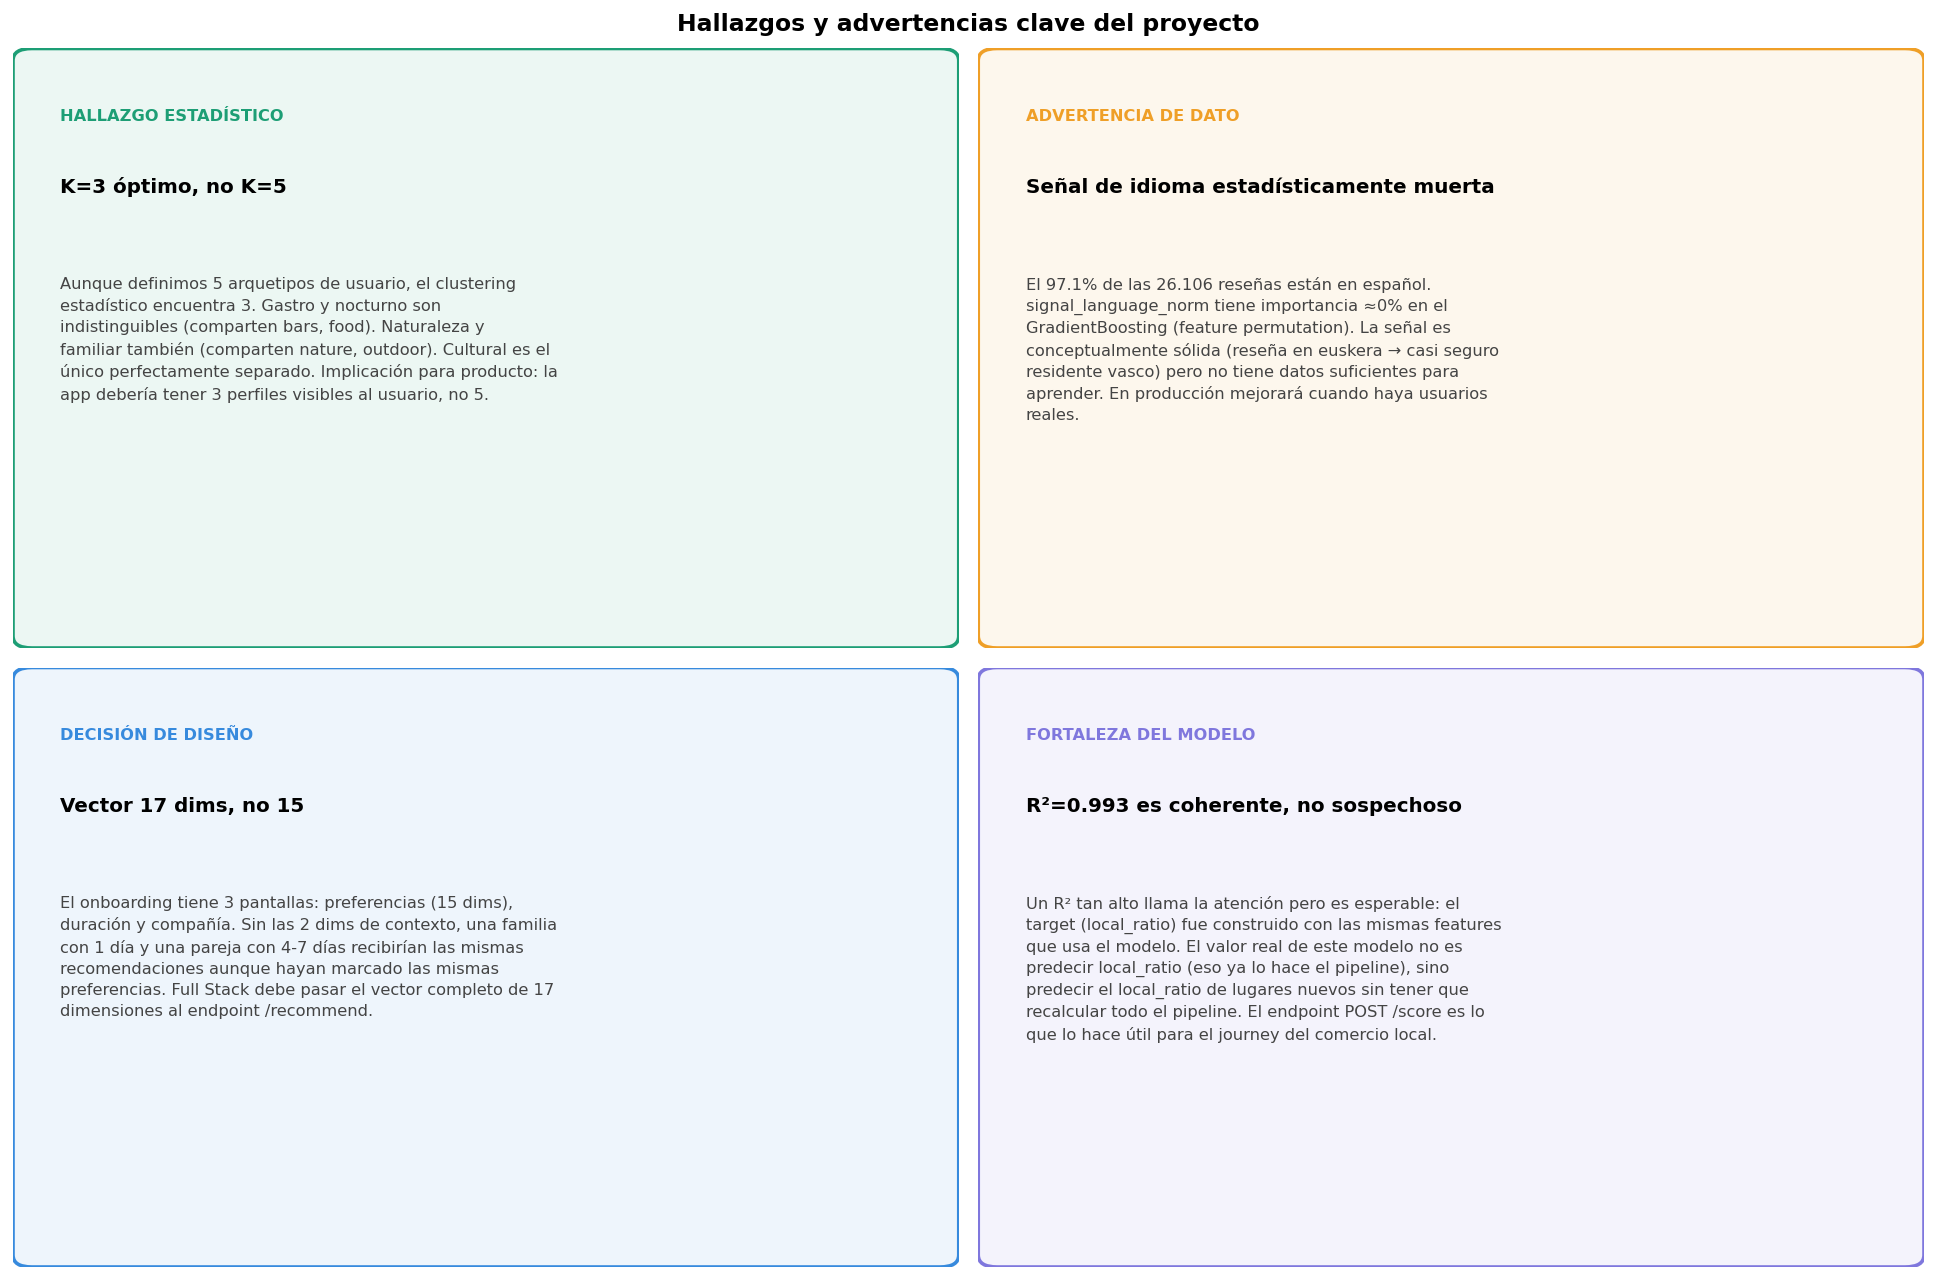

In [16]:
import matplotlib.patches as mpatches
import textwrap

hallazgos = [
    {
        'tipo': 'HALLAZGO ESTADÍSTICO',
        'color': P_TEAL,
        'titulo': 'K=3 óptimo, no K=5',
        'detalle': (
            'Aunque definimos 5 arquetipos de usuario, el clustering estadístico encuentra 3. '
            'Gastro y nocturno son indistinguibles (comparten bars, food). '
            'Naturaleza y familiar también (comparten nature, outdoor). '
            'Cultural es el único perfectamente separado. '
            'Implicación para producto: la app debería tener 3 perfiles visibles al usuario, no 5.'
        )
    },
    {
        'tipo': 'ADVERTENCIA DE DATO',
        'color': P_AMBER,
        'titulo': 'Señal de idioma estadísticamente muerta',
        'detalle': (
            'El 97.1% de las 26.106 reseñas están en español. '
            'signal_language_norm tiene importancia ≈0% en el GradientBoosting (feature permutation). '
            'La señal es conceptualmente sólida (reseña en euskera → casi seguro residente vasco) '
            'pero no tiene datos suficientes para aprender. En producción mejorará cuando haya usuarios reales.'
        )
    },
    {
        'tipo': 'DECISIÓN DE DISEÑO',
        'color': P_BLUE,
        'titulo': 'Vector 17 dims, no 15',
        'detalle': (
            'El onboarding tiene 3 pantallas: preferencias (15 dims), duración y compañía. '
            'Sin las 2 dims de contexto, una familia con 1 día y una pareja con 4-7 días '
            'recibirían las mismas recomendaciones aunque hayan marcado las mismas preferencias. '
            'Full Stack debe pasar el vector completo de 17 dimensiones al endpoint /recommend.'
        )
    },
    {
        'tipo': 'FORTALEZA DEL MODELO',
        'color': P_PURPLE,
        'titulo': 'R²=0.993 es coherente, no sospechoso',
        'detalle': (
            'Un R² tan alto llama la atención pero es esperable: el target (local_ratio) '
            'fue construido con las mismas features que usa el modelo. '
            'El valor real de este modelo no es predecir local_ratio (eso ya lo hace el pipeline), '
            'sino predecir el local_ratio de lugares nuevos sin tener que recalcular todo el pipeline. '
            'El endpoint POST /score es lo que lo hace útil para el journey del comercio local.'
        )
    },
]


fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Hallazgos y advertencias clave del proyecto', fontsize=13, fontweight='bold')

for ax, h in zip(axes.flatten(), hallazgos):
    ax.axis('off')
    ax.add_patch(mpatches.FancyBboxPatch((0.02, 0.02), 0.96, 0.96,
                                         boxstyle='round,pad=0.02',
                                         facecolor=h['color'] + '15',
                                         edgecolor=h['color'], linewidth=2,
                                         transform=ax.transAxes))
    ax.text(0.05, 0.88, h['tipo'], transform=ax.transAxes,
            fontsize=9, color=h['color'], fontweight='bold')
    ax.text(0.05, 0.76, h['titulo'], transform=ax.transAxes,
            fontsize=11, color='black', fontweight='bold')
    
    # Wrap manual: ~60 caracteres por línea
    detalle_wrapped = textwrap.fill(h['detalle'], width=60)
    ax.text(0.05, 0.62, detalle_wrapped, transform=ax.transAxes,
            fontsize=9, color='#444',
            verticalalignment='top', linespacing=1.5,
            multialignment='left')

plt.tight_layout()
plt.savefig('fig_hallazgos.png', bbox_inches='tight', dpi=130)
plt.show()

## Conclusiones generales

En este notebook hemos recorrido el estado completo del proyecto de datos de Aupa a fecha de junio de 2026.

El dataset maestro está en buen estado: 4.655 lugares, 0 NaN en las features clave, el Local Score calculado con 4 señales más el rating normalizado, y un perturbador de desempate aplicado que llevó los scores únicos del 37.6% al 53%.

El Modelo 1 (GradientBoosting) tiene un R² de 0.993 en cross-validación y un MAE de 0.0045, lo que significa un error medio de predicción de menos de medio punto en escala 0-100. El hallazgo más relevante es que la señal de idioma tiene importancia estadística nula en este dataset porque el 97.1% de las reseñas están en español.

El Modelo 2 (KMeans, K=3) encuentra tres perfiles de usuario reales en los datos: Txoko Social (gastronómico y social), Mendi & Familia (naturaleza y actividades en grupo) y Kultura (patrimonio y turismo cultural). El hallazgo más relevante es que los 5 arquetipos que definimos se colapsan en 3 estadísticamente, lo que implica que el producto debería trabajar con 3 perfiles de usuario visibles.

Los bloques pendientes para el 9 de junio son los 6 endpoints de FastAPI, la coordinación con Full Stack y Marketing, y la presentación del pitch del 11.